# Analyse des Ausleihverhaltens von Nextbike anhand von gesammelten Wetterdaten

### Teil 1: Importe und Helfer-Funktion

In [16]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json

plt.style.use("seaborn-v0_8")

### Teil 2: Mit der NextBike-Datenbank verbinden und in pandas datetime object verwandeln

In [17]:
# load nextbike data and calcualte lending proxy
print("Loading NextBike-Data...")
conn = sqlite3.connect('nextbike_data_old.db')

bike_df = pd.read_sql_query("""
    SELECT timestamp, bike_number, available, spot, place_type
    FROM bike_locations
    WHERE timestamp BETWEEN '2025-09-14' AND '2025-10-09'
""", conn)

# convert "timestamp" from the database into a pandas datatime object
bike_df['timestamp'] = pd.to_datetime(bike_df['timestamp'])
bike_df = bike_df.sort_values(['bike_number', 'timestamp'])

# check for lending behaviour --> available 1->0 or spot-change
bike_df['rented'] = (
    (bike_df.groupby('bike_number')['available'].diff() == -1) | 
    (bike_df.groupby('bike_number')['spot'].diff() != 0)
).fillna(0).astype(int)

# set hourly
bike_df['timestamp'] = pd.to_datetime(bike_df['timestamp'], errors='coerce')
bike_df = bike_df.dropna(subset=['timestamp'])

bike_df['date'] = bike_df['timestamp'].dt.date.astype(str)
bike_df['hour'] = bike_df['timestamp'].dt.hour.astype(int)
bike_df['weekday'] = bike_df['timestamp'].dt.weekday.astype(int)

bike_df['day_type_num'] = np.where(bike_df['weekday'] >= 5, 1, 0)

hourly_bikes = bike_df.groupby(['date', 'hour', 'weekday']).agg({
    'rented': 'sum',
    'bike_number': 'nunique'
}).reset_index()
hourly_bikes['rent_rate'] = hourly_bikes['rented'] / hourly_bikes['bike_number']

print("NextBike-Data successfully loaded!")
conn.close()

Loading NextBike-Data...
NextBike-Data successfully loaded!


### Teil 3: Mit Wetter-Datenbank verbinden und in pandas datetime object verwandeln

In [18]:
print("Loading Weather-Data...")
conn_w = sqlite3.connect("Weather_Data_3.db") 

weather_query = """
SELECT time, temp, prcp, wspd FROM karlsruhe_weather_09_2025
UNION ALL
SELECT time, temp, prcp, wspd FROM karlsruhe_weather_10_2025
"""
weather_df = pd.read_sql_query(weather_query, conn_w)
weather_df['time'] = pd.to_datetime(weather_df['time'])
weather_df['date'] = weather_df['time'].dt.date.astype(str)
weather_df['hour'] = weather_df['time'].dt.hour.astype(int)
weather_df['weekday'] = weather_df['time'].dt.weekday.astype(int)

print("Weather-Data successfully loaded!")
conn_w.close()

Loading Weather-Data...
Weather-Data successfully loaded!


### Teil 4: Zusammenführen der erstellten Objekte + Korrelationen setzen

In [20]:
merged = pd.merge(hourly_bikes, weather_df[['date', 'hour', 'temp', 'prcp', 'wspd']], on=['date', 'hour'], how='left')
print("merge successfully!")

# define day-types for celebration-days in the time period (03.10 Tag der Dt. Einheit)
holidays = ['2025-10-03']
merged['date_str'] = merged['date'].astype(str)
merged['day_type'] = np.where(merged['date_str'].isin(holidays), 'Feiertag', np.where(merged['weekday'] >= 5, 'Wochenende', 'Werktag'))

print(f"Data analysed: {len(merged)} Stunden, {merged['day_type'].value_counts().to_dict()}")

merge successfully!
Data analysed: 565 Stunden, {'Werktag': 393, 'Wochenende': 148, 'Feiertag': 24}


### Teil 5: Grafiken erstellen

#### Plot 1: Korrelationen

In [21]:
# set correlation
corrs = {
    'Temperatur': round(merged['rent_rate'].corr(merged['temp']), 3),
    'Niederschlag': round(merged['rent_rate'].corr(merged['prcp']), 3),
    'Wind': round(merged['rent_rate'].corr(merged['wspd']), 3)
}

corrs

{'Temperatur': np.float64(0.266),
 'Niederschlag': np.float64(-0.148),
 'Wind': np.float64(0.061)}

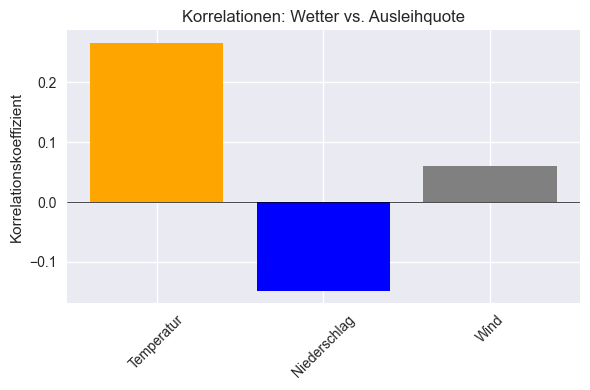

In [22]:
fig, ax = plt.subplots(figsize=(6, 4))

x = range(len(corrs))
ax.bar(x, corrs.values(), color=["orange", "blue", "gray"])
ax.set_xticks(x)
ax.set_xticklabels(corrs.keys(), rotation=45)
ax.set_ylabel("Korrelationskoeffizient")
ax.set_title("Korrelationen: Wetter vs. Ausleihquote")
ax.axhline(0, color="black", lw=0.5)

plt.tight_layout()
plt.show()


#### Plot 2: Tagesverlauf nach Tagstyp

In [24]:
hourly_avg = (
    merged
    .groupby(["hour", "day_type"])["rent_rate"]
    .mean()
    .unstack()
)

hourly_avg.head(5)

day_type,Feiertag,Werktag,Wochenende
hour,,,
0,0.019469,0.011287,0.025845
1,0.014184,0.007052,0.018527
2,0.015957,0.006056,0.014420
3,0.015986,0.006964,0.009843
4,0.003559,0.013896,0.013468


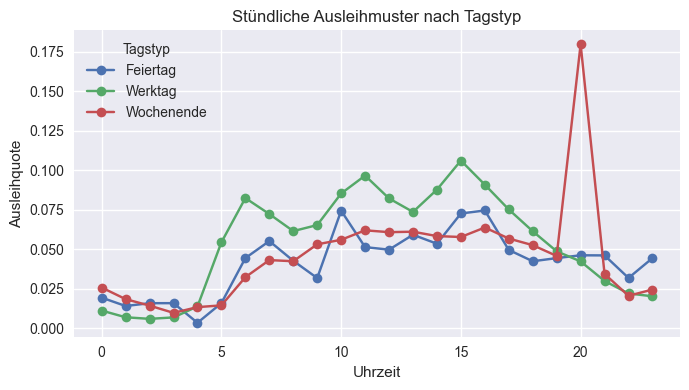

In [25]:
fig, ax = plt.subplots(figsize=(7, 4))

hourly_avg.plot(ax=ax, marker="o")
ax.set_title("Stündliche Ausleihmuster nach Tagstyp")
ax.set_xlabel("Uhrzeit")
ax.set_ylabel("Ausleihquote")
ax.legend(title="Tagstyp")

plt.tight_layout()
plt.show()


#### Plot 3: Ausleihquote nach Temperaturklassen

In [27]:
merged["temp_bin"] = pd.cut(
    merged["temp"],
    bins=5,
    labels=["<5°C", "5–10°C", "10–15°C", "15–20°C", ">20°C"]
)

temp_stats = (
    merged
    .groupby(["day_type", "temp_bin"])["rent_rate"]
    .mean()
    .unstack()
)

temp_stats

C:\Users\benja\AppData\Local\Temp\ipykernel_20036\2461344828.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["day_type", "temp_bin"])["rent_rate"]


temp_bin,<5°C,5–10°C,10–15°C,15–20°C,>20°C
day_type,,,,,
Feiertag,0.032120,0.051282,NaN,NaN,NaN
Werktag,0.044679,0.045213,0.067968,0.078788,0.099078
Wochenende,0.018835,0.032961,0.059533,0.054318,0.090471


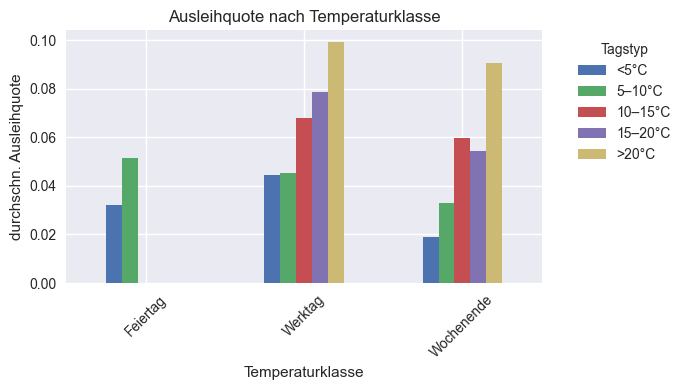

In [28]:
fig, ax = plt.subplots(figsize=(7, 4))

temp_stats.plot(kind="bar", ax=ax)
ax.set_title("Ausleihquote nach Temperaturklasse")
ax.set_xlabel("Temperaturklasse")
ax.set_ylabel("durchschn. Ausleihquote")
ax.legend(title="Tagstyp", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


#### Plot 4: Scatter: Temperatur vs. Ausleihquote

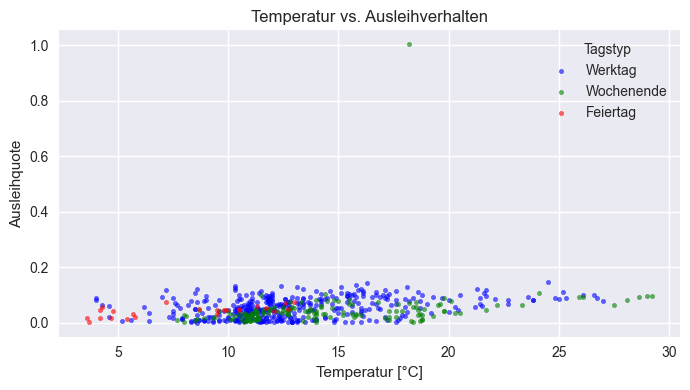

In [29]:
fig, ax = plt.subplots(figsize=(7, 4))

colors = {"Werktag": "blue", "Wochenende": "green", "Feiertag": "red"}

for day_type, color in colors.items():
    subset = merged[merged["day_type"] == day_type]
    ax.scatter(
        subset["temp"],
        subset["rent_rate"],
        c=color,
        label=day_type,
        alpha=0.6,
        s=10
    )

ax.set_xlabel("Temperatur [°C]")
ax.set_ylabel("Ausleihquote")
ax.set_title("Temperatur vs. Ausleihverhalten")
ax.legend(title="Tagstyp")

plt.tight_layout()
plt.show()


### Teil 6: Zusammenfassung

In [30]:
summary_stats = merged.groupby("day_type").agg(
    rent_rate_mean=("rent_rate", "mean"),
    rent_rate_std=("rent_rate", "std"),
    temp_mean=("temp", "mean"),
    prcp_mean=("prcp", "mean"),
    wspd_mean=("wspd", "mean"),
).round(3)

summary_stats


,rent_rate_mean,rent_rate_std,temp_mean,prcp_mean,wspd_mean
day_type,,,,,
Feiertag,0.042,0.020,8.142,0.008,4.446
Werktag,0.054,0.036,13.076,0.239,8.799
Wochenende,0.046,0.083,14.627,0.169,10.671
